# Import Libraries & Load Data

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re , string

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , ops

keras.utils.set_random_seed(1337)
np.random.seed(1337)
tf.random.set_seed(1337)
# load data
train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"

train_df = pd.read_csv(train_url, header=None)
test_df = pd.read_csv(test_url, header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)




Train shape: (120000, 3)
Test shape: (7600, 3)


# Configuration

In [103]:
MAX_TOKENS = 20000
SEQ_LEN = 200
EMBED_DIM = 100
BATCH_SIZE = 64
EPOCHS = 10
RNN_UNITS = 64
LSTM_UNITS = 64
GRU_UNITS = 64

In [104]:
# Naming columns
train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]
# Add Text
train_df['text'] = train_df['title'] + ' ' + train_df['description']
test_df['text'] = test_df['title'] + ' ' + test_df['description']
# drop title and description since i concat them into "text"
train_df.drop(['title', 'description'], axis=1, inplace=True)
test_df.drop(['title', 'description'], axis=1, inplace=True)
# Make Labels from 0 --> 3
train_df["label"] = train_df["label"] - 1
test_df["label"] = test_df["label"] - 1

# Spliting the Data

In [105]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=42,
    stratify=train_df["label"]
)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

train_df.head()

Train samples: 108000
Validation samples: 12000
Test samples: 7600


,label,text
6836,1,10 seconds that change everything ATHENS - Ten...
90699,1,Charline Labonte rises to challenge Charline L...
65214,2,Ex-El Paso Traders Plead Guilty to False Repor...
87713,1,Brit deal #39;one year only Even if British a...
109406,1,"Signed, Sealed, Delivered CHICAGO - The Cubs a..."


# Text Standarization

In [106]:
def custom_standarization(input_data):

  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  clean = tf.strings.regex_replace(stripped_html,f'[{string.punctuation}]','')
  return clean

# Text Vectorization

In [107]:
# Text --> IDs
vectorizer = layers.TextVectorization(
    standardize=custom_standarization,
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN
)

# Learn vocabulary using training text only
vectorizer.adapt(train_df["text"].values)

# Test vectorizer
vocab = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("First 10 tokens:", vocab[:10])

Vocabulary size: 20000
First 10 tokens: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('in'), np.str_('and'), np.str_('on'), np.str_('for')]


In [108]:
# testing for vectorizer
sample_text = train_df["text"].iloc[0]

vectorized_text = vectorizer(sample_text)

print("Original text:")
print(sample_text)

print("\nVectorized text:")
print(vectorized_text.numpy())

print("\nSequence shape:")
print(vectorized_text.shape)

Original text:
10 seconds that change everything ATHENS - Ten seconds. Barely time enough to tie a shoe, wash a glass, get the paper off the porch. But when the moment comes, and eight men kneel at their blocks and peer down the empty, waiting track, it is as if the entire Olympics stop to watch.

Vectorized text:
[ 187 1693   11  629 2582  324 1991 1693 3624   87  802    3 1921    4
 7854 5624    4 5904  198    2 2501  101    2    1   38   78    2 2732
 1073    7  592  510    1   14   34 4499    7 8747  121    2 6480 2384
  990   20   16   13  145    2 2512  699  721    3 1127    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0

# Embeddings

In [110]:
def make_embedding():
  return layers.Embedding(
      input_dim=MAX_TOKENS,
      output_dim=EMBED_DIM,
      mask_zero=True
  )


In [111]:
# apply the vectoriser once, then cache - so we tokenise only a single time

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["text"].values, train_df["label"].values))

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["text"].values, val_df["label"].values))

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["text"].values, test_df["label"].values))

train_ds_vec = (
    train_ds
    .map(lambda x, y: (vectorizer(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000, seed=1337)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds_vec = (
    val_ds
    .map(lambda x, y: (vectorizer(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

test_ds_vec = (
    test_ds
    .map(lambda x, y: (vectorizer(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

for x_batch, y_batch in train_ds_vec.take(1):
    print("Input shape:", x_batch.shape)
    print("Labels shape:", y_batch.shape)

# test embeddings
embedding = make_embedding()
for x_batch, y_batch in train_ds_vec.take(1):
    embedded = embedding(x_batch)

    print("Input shape:", x_batch.shape)
    print("Embedded shape:", embedded.shape)

Input shape: (64, 200)
Labels shape: (64,)
Input shape: (64, 200)
Embedded shape: (64, 200, 100)


# Model-1 Simple RNN

In [112]:
def build_rnn(embedding):
    inputs = keras.Input(shape=(SEQ_LEN,), dtype="int32")
    x = embedding(inputs)
    x = layers.SimpleRNN(RNN_UNITS)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="SimpleRNN")

rnn_embedding = make_embedding()

rnn_model = build_rnn(rnn_embedding)

rnn_model.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 200, 100)  │  2,000,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 200)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_2        │ (None, 64)        │     10,560 │ embedding_7[0][0… │
│ (SimpleRNN)         │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ simple_rnn_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        260 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,010,820 (7.67 MB)

 Trainable params: 2,010,820 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

# Use Early Stopping for All Models

In [113]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# RNN Compile & Training

In [114]:
rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_history = rnn_model.fit(
    train_ds_vec,
    validation_data=val_ds_vec,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.8220 - loss: 0.4837 - val_accuracy: 0.9091 - val_loss: 0.2982
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9154 - loss: 0.2851 - val_accuracy: 0.9096 - val_loss: 0.3086
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9318 - loss: 0.2260 - val_accuracy: 0.9033 - val_loss: 0.3396
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9452 - loss: 0.1810 - val_accuracy: 0.8934 - val_loss: 0.3900
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9544 - loss: 0.1474 - val_accuracy: 0.9009 - val_loss: 0.4033
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


# RNN Evaluation

In [115]:
rnn_loss , rnn_acc = rnn_model.evaluate(test_ds_vec)
print("RNN Loss:", rnn_loss)
print("RNN Accuracy:", rnn_acc)

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9034 - loss: 0.3306
RNN Loss: 0.3306034505367279
RNN Accuracy: 0.9034210443496704


# Loss & Accuracy Curve for RNN

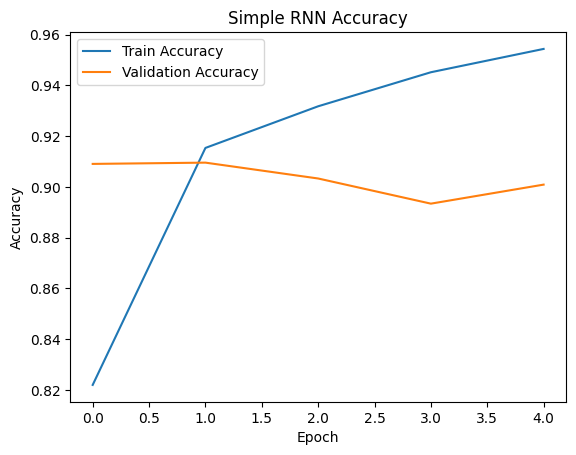

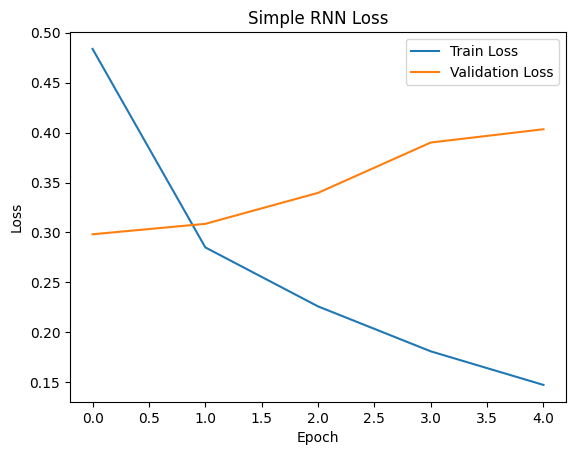

In [116]:
# Accuracy Curve
plt.plot(rnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN Accuracy")
plt.legend()
plt.show()
# Loss Curve
plt.plot(rnn_history.history["loss"], label="Train Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN Loss")
plt.legend()
plt.show()

# Model-2 LSTM

In [117]:
def build_lstm(embedding):
    inputs = keras.Input(shape=(SEQ_LEN,), dtype="int32")
    x = embedding(inputs)
    x = layers.Bidirectional(layers.LSTM(LSTM_UNITS))(x)   # forward + backward pass
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="LSTM")

lstm_embedding = make_embedding()

lstm_model = build_lstm(lstm_embedding)

lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 200, 100)  │  2,000,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 200)       │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     84,480 │ embedding_8[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │        516 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,084,996 (7.95 MB)

 Trainable params: 2,084,996 (7.95 MB)

 Non-trainable params: 0 (0.00 B)

# LSTM Compile & Training

In [118]:
lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    train_ds_vec,
    validation_data=val_ds_vec,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8861 - loss: 0.3371 - val_accuracy: 0.9201 - val_loss: 0.2442
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9333 - loss: 0.2010 - val_accuracy: 0.9165 - val_loss: 0.2493
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9485 - loss: 0.1504 - val_accuracy: 0.9117 - val_loss: 0.2724
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9599 - loss: 0.1122 - val_accuracy: 0.9097 - val_loss: 0.3098
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


# LSTM Evaluation

In [119]:
lstm_loss , lstm_acc = lstm_model.evaluate(test_ds_vec)
print("LSTM Loss:", lstm_loss)
print("LSTM Accuracy:", lstm_acc)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9184 - loss: 0.2506
LSTM Loss: 0.2506383955478668
LSTM Accuracy: 0.9184210300445557


# Loss & Accuracy Curve for LSTM

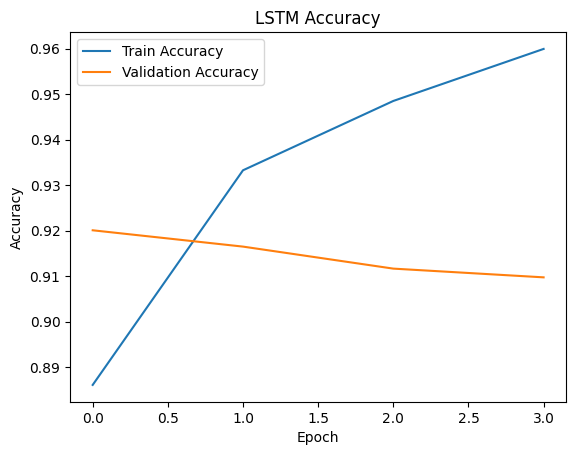

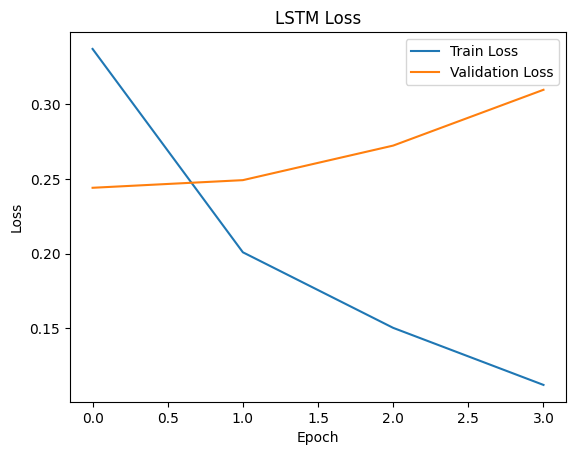

In [120]:
# Accuracy Curve

plt.plot(lstm_history.history["accuracy"], label="Train Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy")
plt.legend()
plt.show()
# Loss Curve
plt.plot(lstm_history.history["loss"], label="Train Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss")
plt.legend()
plt.show()

# Model-3 GRU

In [123]:
def build_gru(embedding):
    inputs = keras.Input(shape=(SEQ_LEN,), dtype="int32")
    x = embedding(inputs)
    x = layers.Bidirectional(layers.GRU(GRU_UNITS))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="GRU")

gru_embedding = make_embedding()

gru_model = build_gru(gru_embedding)

gru_model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 200, 100)  │  2,000,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 200)       │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 128)       │     63,744 │ embedding_11[0][… │
│ (Bidirectional)     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │        516 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,064,260 (7.87 MB)

 Trainable params: 2,064,260 (7.87 MB)

 Non-trainable params: 0 (0.00 B)

# GRU Compile & Training

In [124]:
gru_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

gru_history = gru_model.fit(
    train_ds_vec,
    validation_data=val_ds_vec,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8855 - loss: 0.3385 - val_accuracy: 0.9220 - val_loss: 0.2409
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9335 - loss: 0.1976 - val_accuracy: 0.9172 - val_loss: 0.2505
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9495 - loss: 0.1484 - val_accuracy: 0.9116 - val_loss: 0.2797
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9624 - loss: 0.1081 - val_accuracy: 0.9047 - val_loss: 0.3171
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


# GRU Evaluation

In [125]:
gru_loss , gru_acc = gru_model.evaluate(test_ds_vec)
print("GRU Loss:", gru_loss)
print("GRU Accuracy:", gru_acc)

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9180 - loss: 0.2532
GRU Loss: 0.25323641300201416
GRU Accuracy: 0.918026328086853


# Loss & Accuracy Curve for GRU

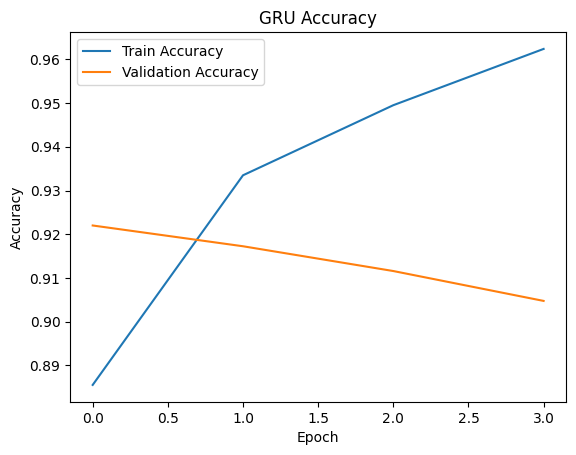

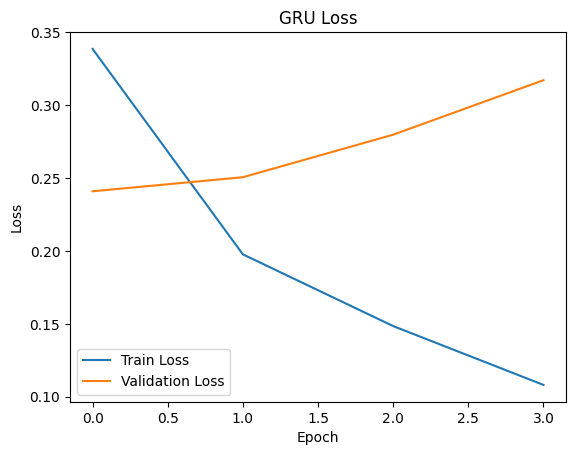

In [126]:
# Accuracy Curve
plt.plot(gru_history.history["accuracy"], label="Train Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Accuracy")
plt.legend()
plt.show()
# Loss Curve
plt.plot(gru_history.history["loss"], label="Train Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Loss")
plt.legend()
plt.show()

# Comparison Between the 3 Mdels

In [132]:
comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],

    "Test Loss": [
        rnn_loss,
        lstm_loss,
        gru_loss
    ],

    "Test Accuracy": [
        rnn_acc,
        lstm_acc,
        gru_acc
    ],

    "Train Loss": [
        rnn_history.history["loss"][-1],
        lstm_history.history["loss"][-1],
        gru_history.history["loss"][-1]
    ],

    "Train Accuracy": [
        rnn_history.history["accuracy"][-1],
        lstm_history.history["accuracy"][-1],
        gru_history.history["accuracy"][-1]
    ],

    "Validation Loss": [
        rnn_history.history["val_loss"][-1],
        lstm_history.history["val_loss"][-1],
        gru_history.history["val_loss"][-1]
    ],

    "Validation Accuracy": [
        rnn_history.history["val_accuracy"][-1],
        lstm_history.history["val_accuracy"][-1],
        gru_history.history["val_accuracy"][-1]
    ]
})

comparison_df.round(4)

,Model,Test Loss,Test Accuracy,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,Simple RNN,0.3306,0.9034,0.1474,0.9544,0.4033,0.9009
1,LSTM,0.2506,0.9184,0.1122,0.9599,0.3098,0.9097
2,GRU,0.2532,0.9180,0.1081,0.9624,0.3171,0.9047


## Final Conclusion

In this project, three recurrent neural network architectures were implemented for AG News text classification: Simple RNN, LSTM, and GRU.

All models were trained using the same training and validation datasets and evaluated on the same test set. The results showed that the **LSTM achieved the best test performance in this experiment**, with a test accuracy of **91.84%** and a test loss of **0.2506**.

The GRU achieved a very similar performance, with a test accuracy of **91.80%** and a test loss of **0.2532**, while the Simple RNN achieved **90.34%** test accuracy with a test loss of **0.3306**.

The training results also show a noticeable gap between training and validation performance, indicating some degree of overfitting. However, the models maintained good validation and test performance overall.

These results demonstrate the differences between basic and gated recurrent architectures for text classification. While the Simple RNN provides a simpler baseline, LSTM and GRU can better capture sequential dependencies in text.

Overall, this project provided practical experience with text cleaning, text vectorization, embeddings, recurrent neural networks, model training, and comparative evaluation.
